# RQ1 — Is Thai Internet Good or Bad? (Ookla, Fixed Broadband, 8-Country SEA Context)

**Question:** Ookla Speedtest Global Index ranks Thailand fixed broadband #13 worldwide (looks good),
but ETDA / consumer-complaint surveys report frequent slow/dropped connections (looks bad).
Instead of arguing from opinion, this notebook answers the question against **concrete
application-requirement thresholds**, following the rubric in Lübben & Misfeld (2022),
*"Exploring the Measurement Lab Open Dataset for Internet Performance Evaluation: The German
Internet Landscape"* (`docs/02-ndt7-mlab/lubben-misfeld-2022-mlab-german-internet-landscape.pdf`, Table 5):

| Application | Data rate | Latency |
|---|---|---|
| Voice | 64 kbps | 200 ms |
| Video streaming (HD) | 5 Mbps | few seconds |
| Video streaming (UHD) | 25 Mbps | few seconds |
| Cloud gaming | 44 Mbps | 25 ms |

Voice's 64 kbps requirement is trivially met by any broadband connection, so it collapses to a
latency-only check here.

**Scope:** Ookla fixed broadband only (mobile deferred). Thailand plus 7 SEA neighbors already in
this repo's exports (Vietnam, Philippines, Singapore, Cambodia, Laos, Malaysia, Myanmar) for
context — Thailand is the focus, the rest are a benchmark, not a full cross-country study.

**Methodology note (limitation to carry into the paper):** each row in these export CSVs is
already a **province × quarter average** (`avg_d_mbps`, `avg_lat_ms_wt`), not a raw per-test
record. "% passing a threshold" below is therefore a **test-count-weighted share of
province-quarters whose average clears the bar**, not a literal % of individual speed tests —
a coarser proxy forced by the data's aggregation level. Weighting by `total_tests` (rather than
a flat per-province-quarter average) at least prevents low-sample provinces from swaying the
national figure as much as high-sample ones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

EXPORTS = Path('../../data/exports')

COUNTRIES = {
    'Thailand':    'ookla_province_quarterly.csv',
    'Vietnam':     'ookla_vietnam_province_quarterly.csv',
    'Philippines': 'ookla_philippines_province_quarterly.csv',
    'Singapore':   'ookla_singapore_province_quarterly.csv',
    'Cambodia':    'ookla_cambodia_province_quarterly.csv',
    'Laos':        'ookla_laos_province_quarterly.csv',
    'Malaysia':    'ookla_malaysia_province_quarterly.csv',
    'Myanmar':     'ookla_myanmar_province_quarterly.csv',
}

frames = []
for country, fname in COUNTRIES.items():
    df = pd.read_csv(EXPORTS / fname)
    df['country'] = country
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df.shape

(2581, 16)

### Data quality check — `is_reliable` already filters at export time

In [2]:
print(all_df.groupby('country')['is_reliable'].value_counts(dropna=False))
print()
print(all_df.groupby('country').size().rename('province_quarter_rows'))

country      is_reliable
Cambodia     True           275
Laos         True           198
Malaysia     True           176
Myanmar      True           139
Philippines  True           187
Singapore    True            55
Thailand     True           847
Vietnam      True           704
Name: count, dtype: int64

country
Cambodia       275
Laos           198
Malaysia       176
Myanmar        139
Philippines    187
Singapore       55
Thailand       847
Vietnam        704
Name: province_quarter_rows, dtype: int64


All rows are `is_reliable == True` in every country's export — the unreliable rows were
already dropped upstream, so no further filtering is needed here.

### Threshold indicators

In [3]:
THRESH = {
    'HD (5 Mbps)':          lambda d: d['avg_d_mbps'] >= 5,
    'UHD (25 Mbps)':        lambda d: d['avg_d_mbps'] >= 25,
    'Cloud gaming (44 Mbps + <=25ms)': lambda d: (d['avg_d_mbps'] >= 44) & (d['avg_lat_ms_wt'] <= 25),
    'Voice latency (<=200ms)': lambda d: d['avg_lat_ms_wt'] <= 200,
}

for label, fn in THRESH.items():
    all_df[label] = fn(all_df)

all_df[list(THRESH.keys())].mean().round(3)

HD (5 Mbps)                        1.000
UHD (25 Mbps)                      0.957
Cloud gaming (44 Mbps + <=25ms)    0.818
Voice latency (<=200ms)            0.999
dtype: float64

### National comparison — test-weighted % of province-quarters clearing each threshold

In [4]:
def weighted_pass_rate(df, col):
    return np.average(df[col], weights=df['total_tests'])

rows = []
for country in COUNTRIES:
    sub = all_df[all_df['country'] == country]
    row = {'country': country, 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('country')
summary_pct = (summary[list(THRESH.keys())] * 100).round(1)
summary_pct['n_tests_total'] = summary['n_tests_total']
summary_pct.sort_values('UHD (25 Mbps)', ascending=False)

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_tests_total
country,,,,,
Thailand,100.0,100.0,99.5,100.0,18948592
Vietnam,100.0,100.0,100.0,100.0,23379226
Philippines,100.0,100.0,92.0,100.0,44431565
Singapore,100.0,100.0,100.0,100.0,4010033
Malaysia,100.0,100.0,97.5,100.0,14527671
Laos,100.0,99.3,60.9,100.0,337542
Cambodia,100.0,97.4,62.8,100.0,2173381
Myanmar,100.0,20.6,0.0,98.1,1692040


### Chart — Thailand highlighted against SEA context

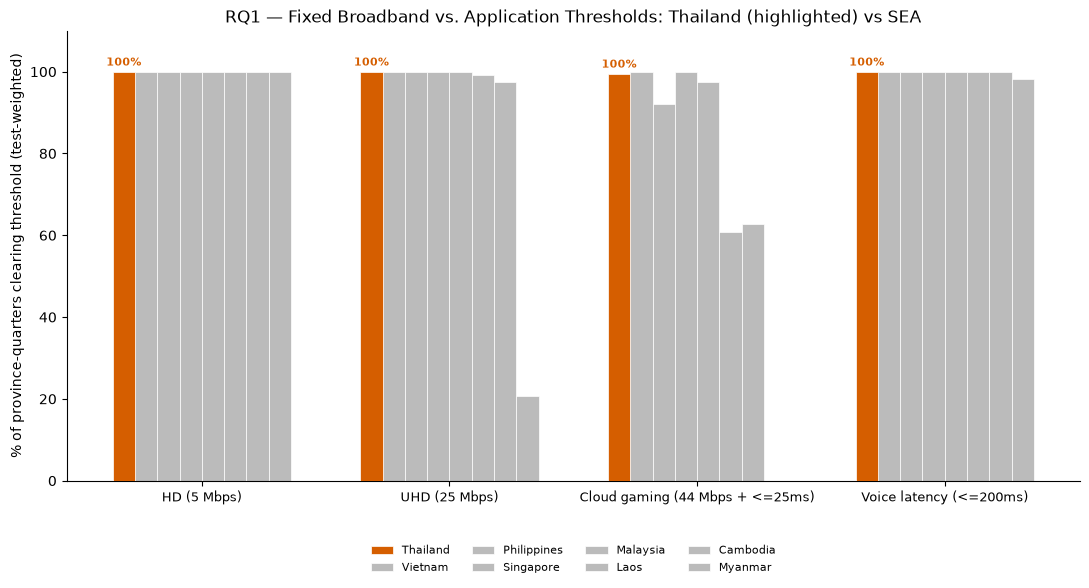

In [5]:
metrics = list(THRESH.keys())
countries_order = summary_pct.sort_values('UHD (25 Mbps)', ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metrics))
width = 0.09

for i, country in enumerate(countries_order):
    color = '#D55E00' if country == 'Thailand' else '#BBBBBB'
    zorder = 3 if country == 'Thailand' else 2
    vals = summary_pct.loc[country, metrics].values
    bars = ax.bar(x + i * width, vals, width, label=country, color=color, zorder=zorder,
                   edgecolor='white', linewidth=0.5)
    if country == 'Thailand':
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f'{val:.0f}%',
                    ha='center', fontsize=8, color='#D55E00', fontweight='bold')

ax.set_xticks(x + width * (len(countries_order) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylabel('% of province-quarters clearing threshold (test-weighted)')
ax.set_ylim(0, 110)
ax.set_title('RQ1 — Fixed Broadband vs. Application Thresholds: Thailand (highlighted) vs SEA')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Thailand — province-level breakdown

**Speed thresholds have zero discriminating power here**: every one of Thailand's 77 provinces
clears HD (5 Mbps), UHD (25 Mbps), *and* the 44 Mbps cloud-gaming data-rate bar in every single
quarter — the minimum province-quarter average download speed in the whole dataset is
~157 Mbps, more than 6x the UHD bar. At this aggregation level, "is fixed broadband fast enough"
is a non-question for Thailand — it says nothing about the ETDA-complaint side of RQ1.

The only threshold with any variance at all is **cloud-gaming latency (<=25 ms)** — so that's
where the province breakdown actually shows something.

In [6]:
th = all_df[all_df['country'] == 'Thailand']
lat_fail = th[th['avg_lat_ms_wt'] > 25][['province', 'quarter', 'avg_d_mbps', 'avg_lat_ms_wt', 'total_tests']]
lat_fail = lat_fail.sort_values('avg_lat_ms_wt', ascending=False)
print(f"{len(lat_fail)} / {len(th)} province-quarters exceed 25ms latency (speed is a non-issue in all of them)")
lat_fail

18 / 847 province-quarters exceed 25ms latency (speed is a non-issue in all of them)


,province,quarter,avg_d_mbps,avg_lat_ms_wt,total_tests
407,Mae Hong Son,2024-Q2,114.846552,219.103620,4227.0
22,Mae Hong Son,2023-Q1,125.867339,176.893943,4441.0
176,Mae Hong Son,2023-Q3,134.461822,158.679201,3856.0
99,Mae Hong Son,2023-Q2,127.043160,154.549400,3917.0
330,Mae Hong Son,2024-Q1,139.408005,142.841306,4411.0
253,Mae Hong Son,2023-Q4,121.528283,136.411168,5122.0
792,Mae Hong Son,2025-Q4,144.154550,124.657455,5681.0
715,Mae Hong Son,2025-Q2,152.823374,84.478864,3028.0
484,Mae Hong Son,2024-Q3,145.508348,55.690361,3320.0
416,Nan,2024-Q2,209.018406,49.217739,6494.0


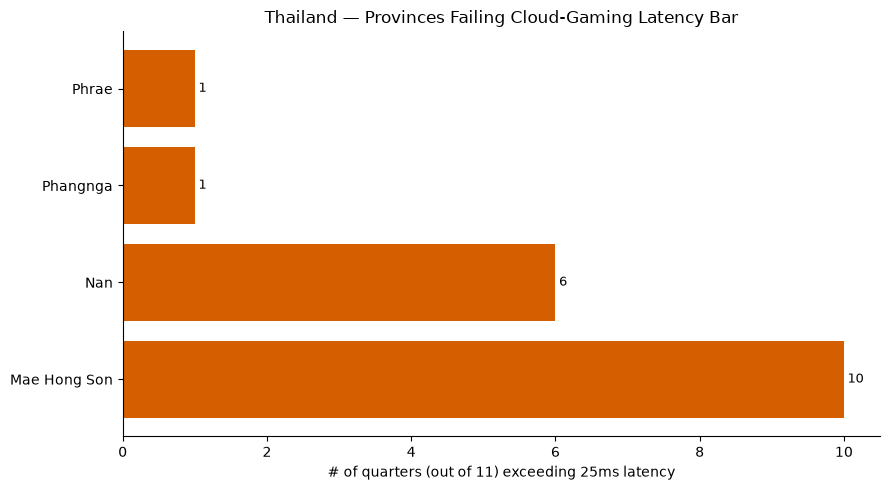

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
by_prov = lat_fail.groupby('province').size().sort_values(ascending=False)
bars = ax.barh(by_prov.index, by_prov.values, color='#D55E00', edgecolor='none')
for bar, val in zip(bars, by_prov.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2, str(val), va='center', fontsize=9)
ax.set_xlabel('# of quarters (out of 11) exceeding 25ms latency')
ax.set_title('Thailand — Provinces Failing Cloud-Gaming Latency Bar')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Key Findings (RQ1, fixed broadband only)

- **HD (5 Mbps) is a non-issue everywhere** — all 8 SEA countries clear it at 100%, and Thailand
  clears it in all 77 provinces across all 11 quarters (min province-quarter average download
  in Thailand is ~157 Mbps). Ookla's "#13 worldwide, fixed broadband is good" framing is fully
  supported *if the question is "is download speed adequate for HD video"* — at province-average
  granularity it isn't even close to a real constraint.
- **UHD (25 Mbps) is where cross-country variance actually shows up**: Thailand/Vietnam/Singapore/
  Malaysia are all at 100%, but **Myanmar drops to 20.6%**, with Cambodia (97.4%) and Laos (99.3%)
  also showing small gaps. For Thailand specifically, UHD is still 100% in every province/quarter —
  no internal variance to report.
- **Cloud-gaming latency is the only threshold with real *within-Thailand* variance**, and it
  isolates a specific, reproducible cause: **Mae Hong Son** (mountainous, remote northern province)
  exceeds 25 ms in **10 of 11 quarters** observed (up to 219 ms in 2024-Q2) — essentially a
  chronic outlier, not a blip. **Nan** joins it in 6 of 11 quarters, with **Phrae** and
  **Phangnga** each showing a single one-off quarter. These four provinces account for effectively
  all of Thailand's ~0.5% national gaming-threshold failure. Regionally this reads as a
  last-mile/backhaul geography story (remote/upland provinces far from IX/server infrastructure),
  not a broad national problem.
- **This is the key methodological finding for RQ1, not just a Thailand result:** province-quarter
  *averages* cannot see the ETDA-complaint side of the story at all — a metric with zero variance
  across 847 province-quarters (SEA-wide, speed) cannot explain user complaints about slow/dropped
  connections. Complaints are almost certainly about **tail behavior** (bad minutes/sessions,
  not average quarters) and/or **reliability/uptime**, which this dataset's granularity structurally
  cannot capture. Resolving the Ookla-vs-ETDA tension needs either NDT7 test-level (not
  province-quarter-averaged) data, or a percentile-based cut (e.g. p10/p25 download, not mean) —
  flag as the concrete next step, and as a paper-methodology limitation regardless of what's done
  next.
- **Not yet done:** same analysis on the mobile/cellular exports (`ookla_mobile_*_province_quarterly.csv`)
  — deferred per scope agreed with user (fixed broadband first). Mobile is the more plausible
  place to find real speed-threshold variance, since cellular last-mile is far less uniform than
  fiber/FTTH.
- **Limitation:** province-quarter-average pass rate, not per-test — see methodology note above.